# Projet Airbnb — Prediction du log_price
Fait par Sousa Jaime, Simon Anne-Gaelle, TDR

L'objectif de ce projet est de prédire le `log_price`, c'est-à-dire le logarithme naturel du prix de location d'un logement Airbnb, à partir de ses caractéristiques (type de logement, ville, équipements, etc.).



## 1. Exploration Qualitative des données

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error

C1,C2,C3,C4 = '#2C7BB6','#D7191C','#1A9641','#FDAE61'# code couleur pour les graphes
plt.rcParams.update({'figure.dpi':110,'axes.spines.top':False,'axes.spines.right':False,
                     'axes.grid':True,'grid.alpha':0.25,'grid.linestyle':'--'})
#configure le style des graphes qui suivront


In [36]:
train = pd.read_csv("airbnb_train.csv")
test  = pd.read_csv("airbnb_test.csv")
test  = test.rename(columns={"Unnamed: 0": "id"}) #on renomme la 1e colonne qui est unamed dans le csv

In [37]:
print(f"Train : {train.shape[0]:,} lignes  x  {train.shape[1]} colonnes")
print(f"Test  : {test.shape[0]:,} lignes  x  {test.shape[1]} colonnes")


Train : 22,234 lignes  x  28 colonnes
Test  : 51,877 lignes  x  27 colonnes


In [38]:
train.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5708593,4.317488,House,Private room,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",3,1.0,Real Bed,flexible,False,...,NaN,33.782712,-118.134410,Island style Spa Studio,Long Beach,0,NaN,90804,0.0,2.0
1,14483613,4.007333,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",4,2.0,Real Bed,strict,False,...,2017-09-17,40.705468,-73.909439,"Beautiful and Simple Room W/2 Beds, 25 Mins to...",Ridgewood,38,86.0,11385,1.0,2.0
2,10412649,7.090077,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",6,2.0,Real Bed,flexible,False,...,NaN,38.917537,-77.031651,2br/2ba luxury condo perfect for infant / toddler,U Street Corridor,0,NaN,20009,2.0,2.0
3,17954362,3.555348,House,Private room,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",1,1.0,Real Bed,flexible,True,...,2017-09-29,40.736001,-73.924248,Manhattan view from Queens. Lovely single room .,Sunnyside,19,96.0,11104,1.0,1.0
4,9969781,5.480639,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,moderate,True,...,2017-08-28,37.744896,-122.430665,Zen Captured Noe Valley House,Noe Valley,15,96.0,94131,2.0,2.0


In [39]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22234 entries, 0 to 22233
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      22234 non-null  int64  
 1   log_price               22234 non-null  float64
 2   property_type           22234 non-null  object 
 3   room_type               22234 non-null  object 
 4   amenities               22234 non-null  object 
 5   accommodates            22234 non-null  int64  
 6   bathrooms               22183 non-null  float64
 7   bed_type                22234 non-null  object 
 8   cancellation_policy     22234 non-null  object 
 9   cleaning_fee            22234 non-null  bool   
 10  city                    22234 non-null  object 
 11  description             22234 non-null  object 
 12  first_review            17509 non-null  object 
 13  host_has_profile_pic    22178 non-null  object 
 14  host_identity_verified  22178 non-null

Les variables numériques ont des échelles très différentes. On le vérifie avec `describe()` — c'est ce qui justifie la standardisation plus tard.

In [40]:
train[['log_price','accommodates','bathrooms','bedrooms','beds',
       'number_of_reviews','review_scores_rating']].describe().round(2)

,log_price,accommodates,bathrooms,bedrooms,beds,number_of_reviews,review_scores_rating
count,22234.00,22234.00,22183.00,22208.00,22199.00,22234.00,17256.00
mean,4.78,3.16,1.24,1.26,1.71,20.67,94.07
std,0.72,2.14,0.59,0.85,1.25,37.18,7.78
min,2.30,1.00,0.00,0.00,0.00,0.00,20.00
25%,4.32,2.00,1.00,1.00,1.00,1.00,92.00
50%,4.70,2.00,1.00,1.00,1.00,6.00,96.00
75%,5.22,4.00,1.00,1.00,2.00,23.00,100.00
max,7.60,16.00,8.00,10.00,18.00,505.00,100.00


La standardisation `StandardScaler` ramènera toutes ces variables à moyenne 0 et écart-type 1, indispensable pour la descente de gradient et le SVR.

In [41]:
cols_num = ['log_price','accommodates','bathrooms','bedrooms','beds',
            'number_of_reviews','review_scores_rating','latitude','longitude']

print(f"  {'Variable':<25} {'Min':>8}  {'Max':>8}  {'Amplitude':>10}")
print("  " + "-"*57)
for col in cols_num:
    mn  = train[col].min()
    mx  = train[col].max()
    print(f"  {col:<25} {mn:>8.1f}  {mx:>8.1f}  {mx - mn:>10.1f}")

print()
print("Les variables ont des échelles très différentes et donc des amplitudes à échelle différentes aussi.")
print("C'est pour cela qu'on va standardiser les données avec standardscaler.")

  Variable                       Min       Max   Amplitude
  ---------------------------------------------------------
  log_price                      2.3       7.6         5.3
  accommodates                   1.0      16.0        15.0
  bathrooms                      0.0       8.0         8.0
  bedrooms                       0.0      10.0        10.0
  beds                           0.0      18.0        18.0
  number_of_reviews              0.0     505.0       505.0
  review_scores_rating          20.0     100.0        80.0
  latitude                      33.3      42.4         9.1
  longitude                   -122.5     -71.0        51.5

Les variables ont des échelles très différentes et donc des amplitudes à échelle différentes aussi.
C'est pour cela qu'on va standardiser les données avec standardscaler.


##  Valeurs Manquantes

In [42]:
# On identifie les valeurs manquentes
missing = train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_pct = (missing / len(train) * 100).round(2)
pd.DataFrame({'Nb manquants': missing, '% manquant': missing_pct})

,Nb manquants,% manquant
host_response_rate,5475,24.62
review_scores_rating,4978,22.39
first_review,4725,21.25
last_review,4716,21.21
neighbourhood,2086,9.38
zipcode,303,1.36
host_identity_verified,56,0.25
host_since,56,0.25
host_has_profile_pic,56,0.25
bathrooms,51,0.23


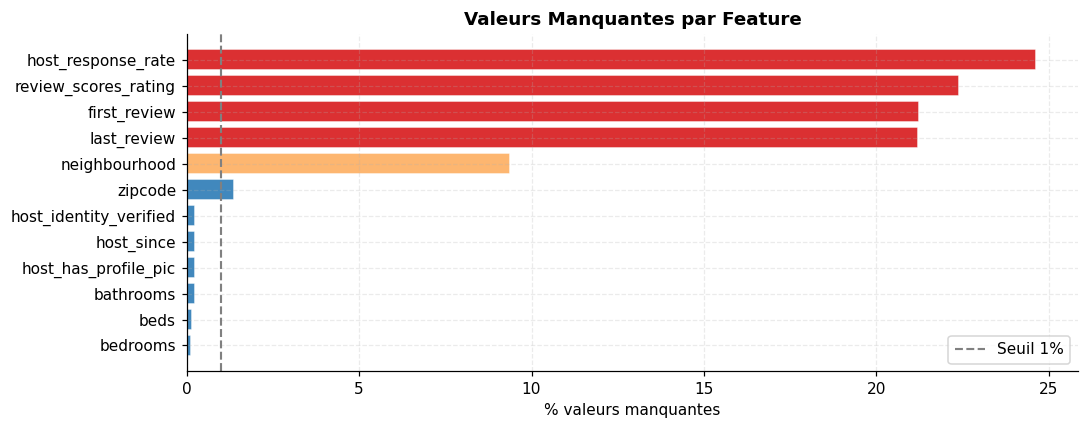

In [43]:
fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = []
for v in missing_pct.values:
    if v > 20:
        bar_colors.append(C2)  
    elif v > 5:
        bar_colors.append(C4)  
    else:
        bar_colors.append(C1)   

ax.barh(missing.index, missing_pct.values,
        color=bar_colors, edgecolor='white', alpha=0.9)

ax.axvline(1, color='gray', lw=1.4, ls='--', label='Seuil 1%')

ax.set_xlabel('% valeurs manquantes')
ax.set_title('Valeurs Manquantes par Feature', fontweight='bold')
ax.legend()
ax.invert_yaxis() 

plt.tight_layout()
plt.show()

**Décision par cas :**

- **< 1%** (`bathrooms`, `beds`, `bedrooms`, `host_since`) : moins de 56 lignes concernées. Imputation par la **médiane**, plus robuste que la moyenne face aux valeurs extrêmes. On ne supprime pas car le jeu de test présente les mêmes manques.

- **~9%** (`neighbourhood`) : Trop de categories distinctes pour un one-hot encoding (explosion de colonnes). On applique un frequency encoding : chaque quartier est remplace par son nombre d'apparitions dans le train, ce qui capture sa popularite.
ex: "Williamsburg" apparait 300 fois => 300, un quartier rare apparait 5 fois => 5. 
Cela capture indirectement la popularite du quartier sans ajouter de colonnes supplementaires.

- **>20%** (`host_response_rate`, `review_scores_rating`, `first_review`, `last_review`) : ces manques correspondent aux logements sans aucun avis. On crée `has_reviews` (0/1) pour capturer cette information, puis on impute les numériques par la médiane.

**Aucune ligne supprimée** : le jeu de test contient les mêmes patterns de manquants.


## Distribution du log_price

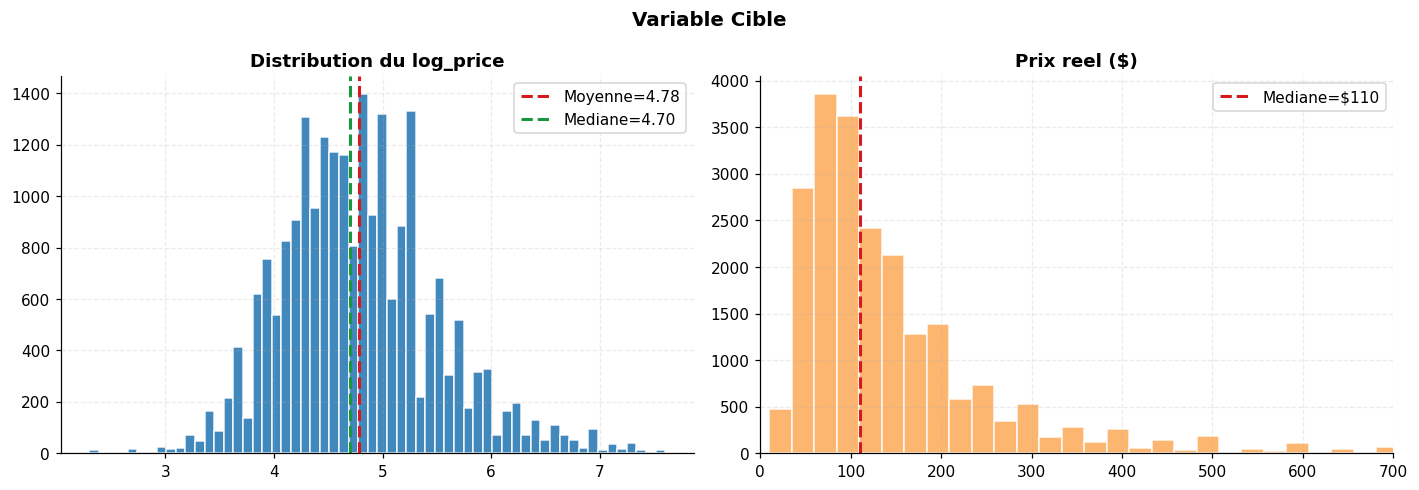

In [44]:
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
# Histogramme log_price
axes[0].hist(train['log_price'],bins=60,color=C1,edgecolor='white',alpha=0.9)
axes[0].axvline(train['log_price'].mean(),color=C2,lw=2,ls='--',label=f"Moyenne={train['log_price'].mean():.2f}")
axes[0].axvline(train['log_price'].median(),color=C3,lw=2,ls='--',label=f"Mediane={train['log_price'].median():.2f}")
axes[0].set_title('Distribution du log_price',fontweight='bold'); axes[0].legend()
# Prix reel
prices=np.exp(train['log_price']) #Comme log_price = ln(prix), on a prix = e^(log_price)
axes[1].hist(prices,bins=80,color=C4,edgecolor='white',alpha=0.9)
axes[1].axvline(prices.median(),color=C2,lw=2,ls='--',label=f'Mediane=${prices.median():.0f}')
axes[1].set_xlim(0,700); axes[1].set_title('Prix reel ($)',fontweight='bold'); axes[1].legend()
plt.suptitle('Variable Cible',fontsize=13,fontweight='bold'); plt.tight_layout(); plt.show()

Le graphique de gauche montre que le `log_price` suit une distribution **quasi-normale** : moyenne et médiane sont proches (4.78 vs 4.70). C'est une propriété favorable pour les modèles linéaires.

Le graphique de droite montre le prix réel en dollars : la distribution est fortement asymétrique à droite avec quelques logements à plus de 700$/nuit. C'est pourquoi on prédit le **log du prix** plutôt que le prix brut : le logarithme normalise cette asymétrie.


## Prix en Fonction de la Distance du Centre-Ville

On calcule la distance géodésique (formule de Haversine) entre chaque logement et le centre de sa ville. C'est une feature clé : plus on est loin du centre, moins le logement est cher en général — sauf pour quelques grandes propriétés en périphérie.


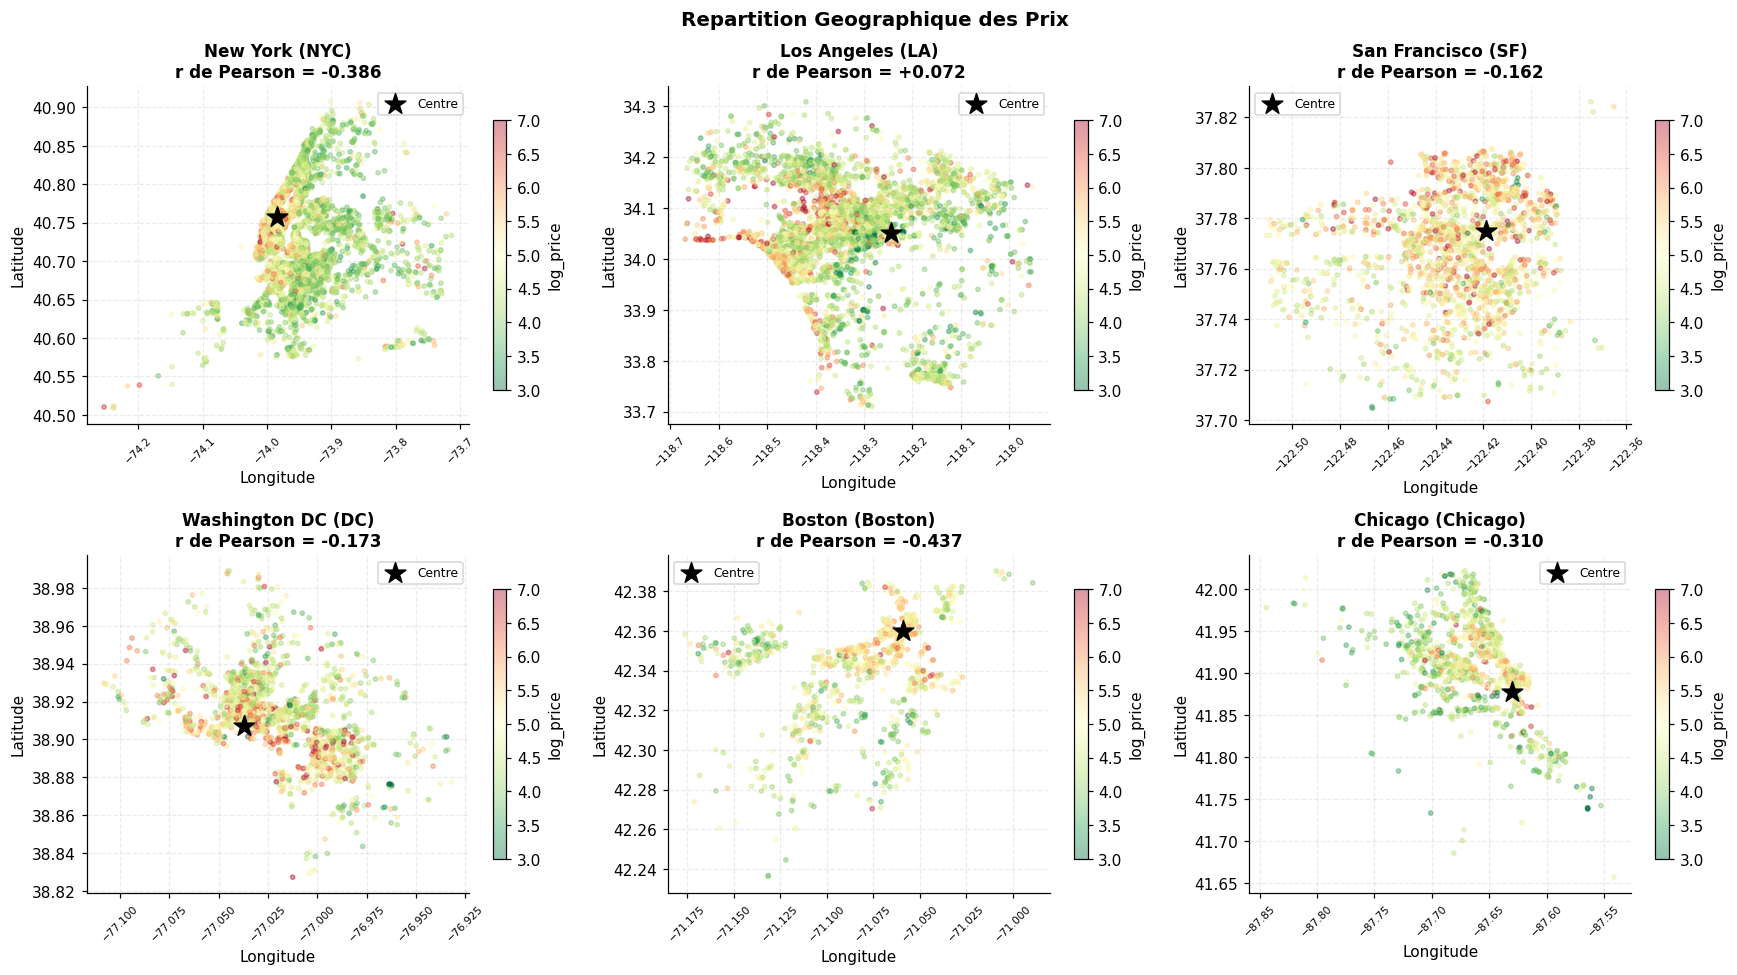

Colonne dist_center_km calculee : 22,234 valeurs valides


In [45]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    a = (np.sin(np.radians(lat2 - lat1) / 2) ** 2
         + np.cos(phi1) * np.cos(phi2) * np.sin(np.radians(lon2 - lon1) / 2) ** 2)
    return 2 * R * np.arcsin(np.sqrt(a))

CITY_CTR = {
    'NYC': (40.758, -73.985),  'LA':  (34.052, -118.244),
    'SF':  (37.775, -122.419), 'DC':  (38.907, -77.037),
    'Boston': (42.360, -71.059), 'Chicago': (41.878, -87.630),
}
CITY_BOUNDS = {
    'NYC':    (40.47, 40.93, -74.27, -73.68),
    'LA':     (33.70, 34.35, -118.67, -117.95),
    'SF':     (37.67, 37.85, -122.53, -122.33),
    'DC':     (38.79, 38.99, -77.15, -76.92),
    'Boston': (42.23, 42.45, -71.19, -70.98),
    'Chicago':(41.63, 42.05, -87.90, -87.50),
}
CITY_FULL = {
    'NYC': 'New York', 'LA': 'Los Angeles', 'SF': 'San Francisco',
    'DC':  'Washington DC', 'Boston': 'Boston', 'Chicago': 'Chicago',
}
CITY_COLORS = {'NYC': C1, 'LA': C2, 'SF': C3, 'DC': C4,
               'Boston': '#7B2D8B', 'Chicago': '#00AABB'}

train['dist_center_km'] = train.apply(
    lambda r: haversine(r['latitude'], r['longitude'], *CITY_CTR[r['city']])
    if r['city'] in CITY_CTR else np.nan, axis=1)

city_order = ['NYC', 'LA', 'SF', 'DC', 'Boston', 'Chicago']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, city in enumerate(city_order):
    ax = axes[i]
    bounds = CITY_BOUNDS[city]
    d = train[train['city'] == city].copy()
    d = d[(d['latitude'].between(bounds[0], bounds[1])) &
          (d['longitude'].between(bounds[2], bounds[3]))]
    d = d.dropna(subset=['dist_center_km', 'log_price'])

    sc = ax.scatter(d['longitude'], d['latitude'],
                    c=d['log_price'], cmap='RdYlGn_r',
                    alpha=0.4, s=8, vmin=3, vmax=7)

    clat, clon = CITY_CTR[city]
    ax.scatter(clon, clat, color='black', marker='*', s=200, zorder=5, label='Centre')

    plt.colorbar(sc, ax=ax, shrink=0.8, label='log_price')

    r = d['dist_center_km'].corr(d['log_price'])
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'{CITY_FULL[city]} ({city})\nr de Pearson = {r:+.3f}',
                 fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)

fig.suptitle('Repartition Geographique des Prix',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Colonne dist_center_km calculee : {train['dist_center_km'].notna().sum():,} valeurs valides")

Sur la carte, les points rouges (prix élevés) se concentrent autour de l'étoile et deviennent verts en s'éloignant. Cette tendance se confirme avec le r de Pearson : **Boston (−0.44)**, **NYC (−0.39)** et **Chicago (−0.31)** ont une corrélation négative nette.

**Cas particulier de Los Angeles** (r = +0.05) : ville polycentrique sans centre dominant, la distance n'y est pas un bon prédicteur du prix. La distance a un centre unique ne veut donc rien dire pour cette ville.Le modèle s'appuiera sur `latitude` et `longitude` brutes pour cette ville.


## Prix en Fonction du Type de Logement

La nature du logement est un facteur déterminant pour le prix. On s'attend à une différence claire entre les types de chambre et les types de propriété.

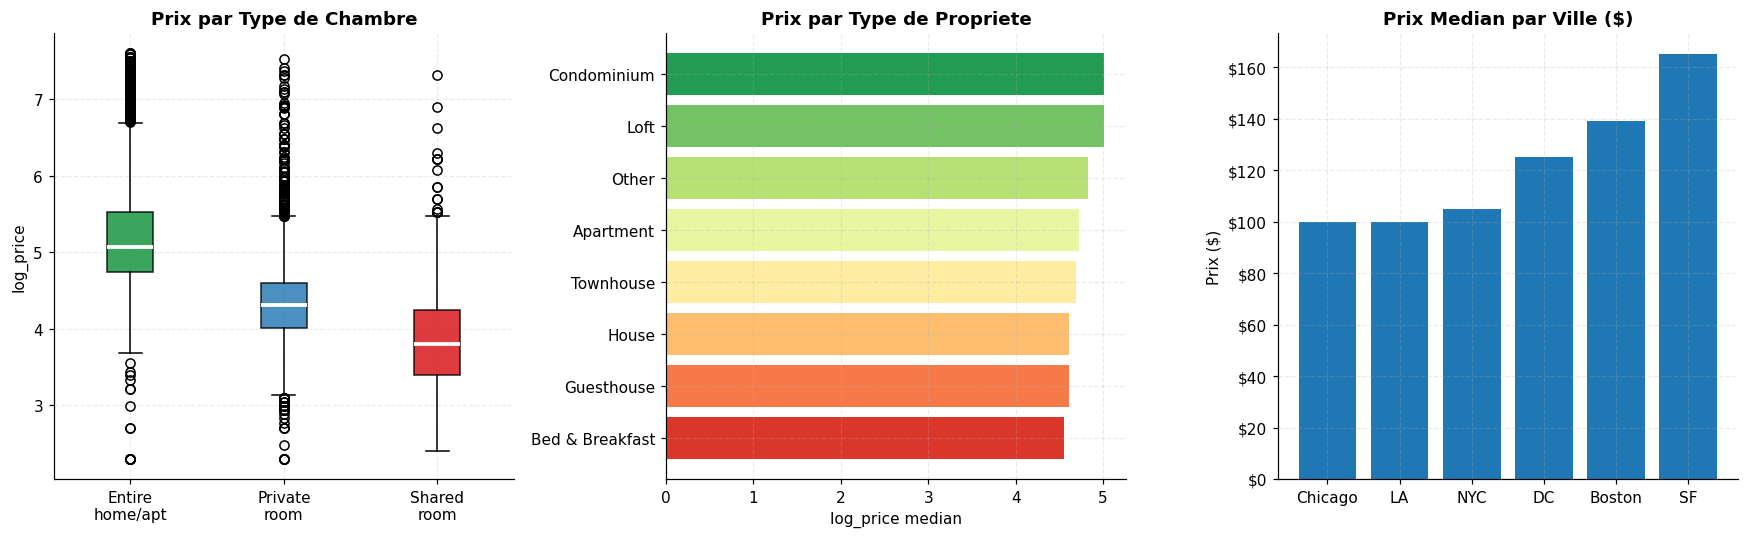

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# log_price par type de chambre 
room_order = (train.groupby('room_type')['log_price'].median().sort_values(ascending=False).index.tolist())
data_by_room = [train[train['room_type'] == rt]['log_price'].values for rt in room_order]
bp = axes[0].boxplot(data_by_room, patch_artist=True,
                     medianprops=dict(color='white', lw=2.5))
for patch, color in zip(bp['boxes'], [C3, C1, C2]):
    patch.set(facecolor=color, alpha=0.85)
axes[0].set_xticklabels([rt.replace(' ', '\n') for rt in room_order])
axes[0].set_title('Prix par Type de Chambre', fontweight='bold')
axes[0].set_ylabel('log_price')

# prix median par type de propriete (8 plus fréquents)
top_props = train['property_type'].value_counts().head(8).index
prop_med = (train[train['property_type'].isin(top_props)].groupby('property_type')['log_price'].median().sort_values())

axes[1].barh(prop_med.index, prop_med.values,
             color=sns.color_palette('RdYlGn', len(prop_med)))
axes[1].set_title('Prix par Type de Propriete', fontweight='bold')
axes[1].set_xlabel('log_price median')

# prix median reel en dollars par ville
city_order = (train.groupby('city')['log_price'].median().sort_values().index.tolist())

prix_median_par_ville = [np.exp(train[train['city'] == c]['log_price'].median())
                         for c in city_order]

axes[2].bar(city_order, prix_median_par_ville)
axes[2].set_title('Prix Median par Ville ($)', fontweight='bold')
axes[2].set_ylabel('Prix ($)')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))

plt.tight_layout()
plt.show()

`room_type` est très discriminant : Entire home (~160$/nuit) vs Shared room (~45$/nuit), soit un facteur **3.5x**. C'est la variable la plus impactante après la localisation.

Pour les villes, SF est la plus chère (~165$/nuit) et Chicago la moins chère (~100$/nuit).


On prefere l'encodage ordinal au one-hot encoding pour deux raisons :
L'ordre est significatif : une chambre entiere coute toujours plus cher qu'une chambre privee, qui coute toujours plus cher qu'une chambre partagee.

Remplacer Shared=0, Private=1, Entire=2 capture cette progression naturelle.

city       : Chicago(0) < LA(1) < DC(2) < Boston(3) < NYC(4) < SF(5)

Le one-hot encoding creerait une colonne par categorie et le modele devrait le reapprendre lui-meme a partir de colonnes binaires independantes.

## Matrice de Corrélation — Features Impactantes

La matrice de corrélation permet d'identifier les variables les plus liées au prix et de détecter les redondances entre features (multicolinéarité).

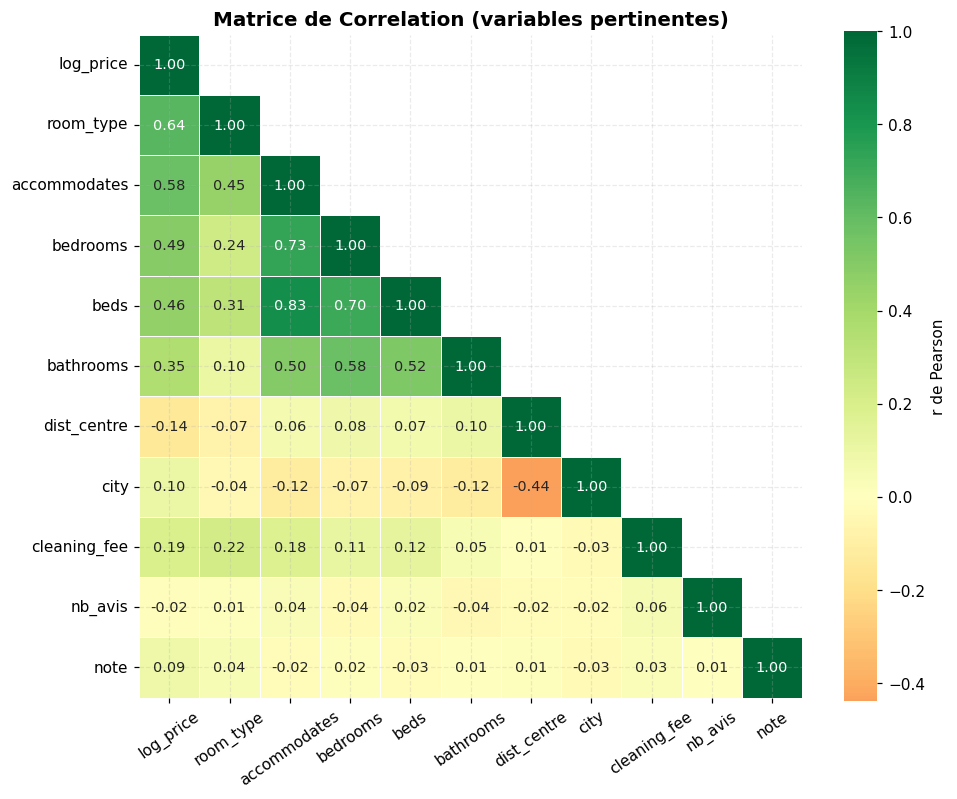

In [47]:
# Matrice de correlation
# On calcule ici les encodages necessaires s'ils ne sont pas encore presents

if 'room_type_enc' not in train.columns:
    train['room_type_enc'] = train['room_type'].map(
        {'Shared room':0, 'Private room':1, 'Entire home/apt':2}).fillna(0)
if 'city_enc' not in train.columns:
    train['city_enc'] = train['city'].map(
        {'Chicago':0,'LA':1,'DC':2,'Boston':3,'NYC':4,'SF':5}).fillna(0)
if 'cleaning_fee_n' not in train.columns:
    train['cleaning_fee_n'] = train['cleaning_fee'].map({True:1,False:0}).fillna(0)

corr_cols_select = ['log_price','room_type_enc','accommodates','bedrooms','beds',
                    'bathrooms','dist_center_km','city_enc','cleaning_fee_n',
                    'number_of_reviews','review_scores_rating']
corr_labels = ['log_price','room_type','accommodates','bedrooms','beds',
               'bathrooms','dist_centre','city','cleaning_fee','nb_avis','note']

corr_mat = train[corr_cols_select].dropna().corr()
corr_mat.columns = corr_labels
corr_mat.index   = corr_labels

fig, ax = plt.subplots(figsize=(9, 8))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, square=True, linewidths=0.6, ax=ax,
            annot_kws={'size': 9.5},
            cbar_kws={'label': 'r de Pearson', 'shrink': 0.85})
ax.set_title('Matrice de Correlation (variables pertinentes)',
             fontweight='bold', fontsize=13)
ax.tick_params(axis='x', rotation=35, labelsize=10)
ax.tick_params(axis='y', rotation=0,  labelsize=10)
plt.tight_layout()
plt.show()

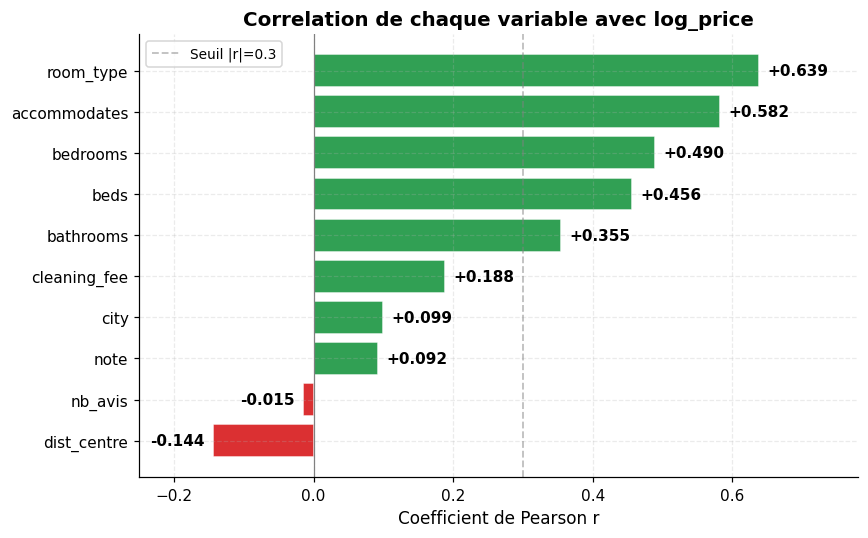

In [48]:
# Correlation de chaque variable avec log_price
corr_lp = corr_mat['log_price'].drop('log_price').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
bar_c = [C2 if v < 0 else C3 for v in corr_lp.values]
bars = ax.barh(corr_lp.index, corr_lp.values, color=bar_c, edgecolor='white', alpha=0.9)
ax.axvline(0, color='gray', lw=0.8)
ax.axvline( 0.3, color='gray', lw=1.2, ls='--', alpha=0.5, label='Seuil |r|=0.3')
ax.axvline(-0.3, color='gray', lw=1.2, ls='--', alpha=0.5)
ax.set_xlabel('Coefficient de Pearson r', fontsize=11)
ax.set_title('Correlation de chaque variable avec log_price',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
for bar, v in zip(bars, corr_lp.values):
    xp = v + 0.012 if v >= 0 else v - 0.012
    ax.text(xp, bar.get_y() + bar.get_height()/2,
            f'{v:+.3f}', va='center',
            ha='left' if v >= 0 else 'right',
            fontsize=10, fontweight='bold')
ax.set_xlim(-0.25, 0.78)
plt.tight_layout()
plt.show()

**Variables fortement corrélées entre elles**

`room_type`, `accommodates`, `bedrooms` et `beds` ont toutes r > 0.7 entre elles car ce sont toutes des mesures de la taille du logement. Un grand appartement a beaucoup de chambres, de lits et accueille plus de voyageurs. On les garde toutes car chacune apporte une nuance différente, et la régularisation Ridge gérera la multicolinéarité en pénalisant les coefficients trop grands.

**Variables à faible impact sur log_price**

`nb_avis` (r = −0.02) et `note` (r = +0.09) ont une corrélation quasi nulle avec le prix. Un logement bien noté n'est pas forcément cher, et un logement populaire est souvent abordable car il tourne vite. On les conserve dans le modèle mais elles auront un poids très faible.

`dist_centre` (r = −0.14) : la corrélation est réelle mais modeste car l'effet varie selon la ville — fort à Boston et NYC, quasi nul à LA comme on l'a vu sur les cartes.

**Variables retenues à fort impact (|r| > 0.3)**

Les variables au-delà du seuil |r| = 0.3 ont un impact significatif sur le prix : `room_type`, `accommodates`, `bedrooms`, `beds`, `bathrooms`. Ce sont les variables sur lesquelles le modèle va s'appuyer en priorité pour prédire le log_price.

## Traitement des Valeurs Extremes

**Methode**
On considere qu'une valeur est extreme si elle est en dehors de l'intervalle
$[Q1 - 1.5 \times IQR,\ Q3 + 1.5 \times IQR]$.


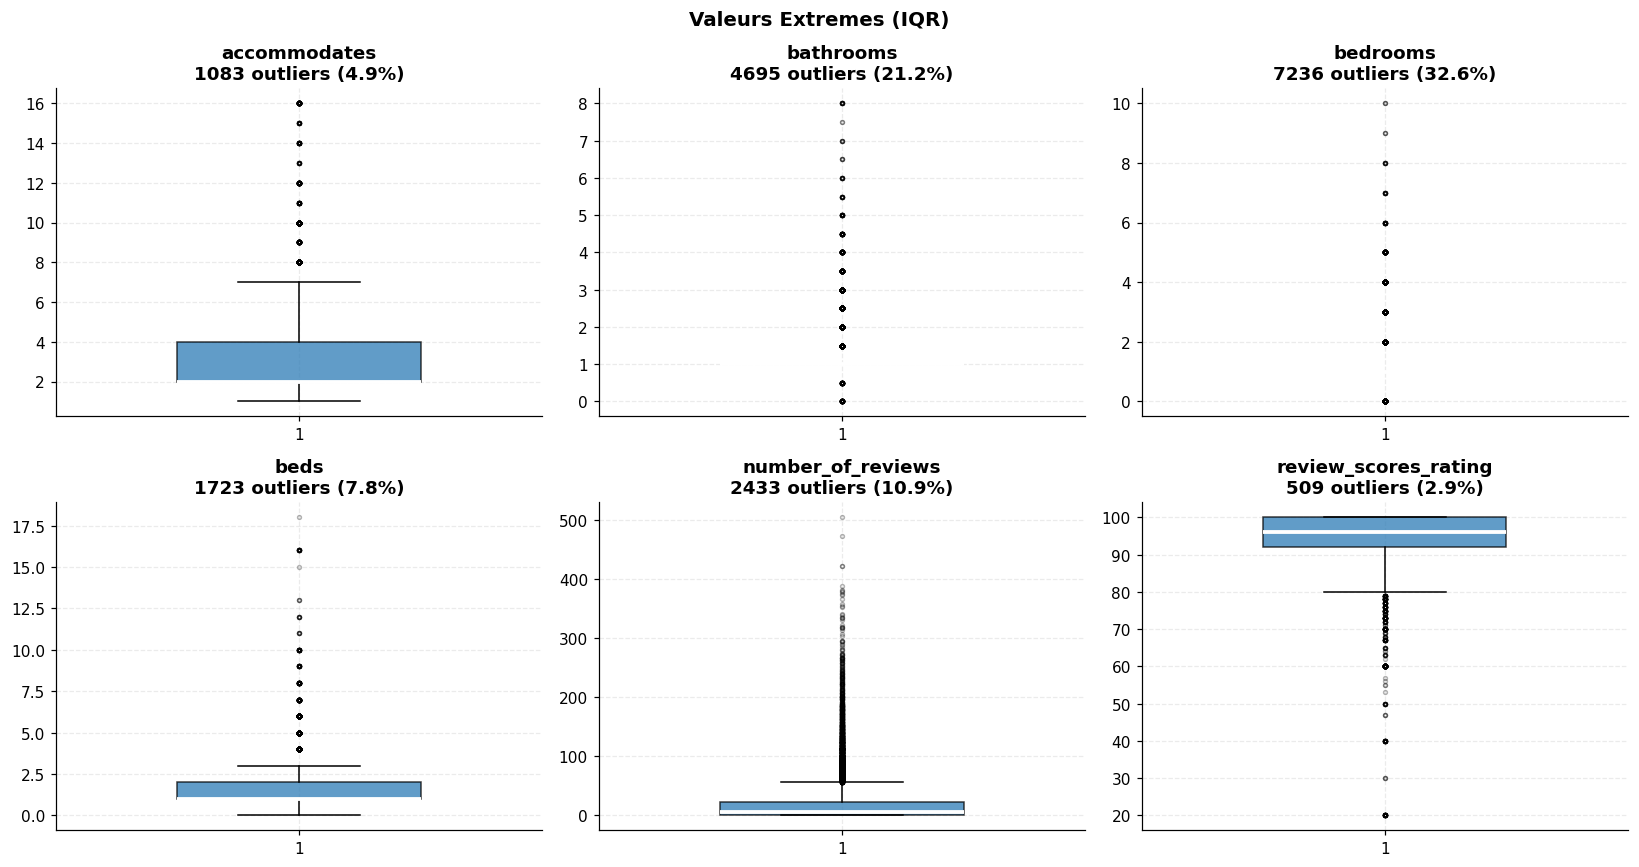

In [49]:
fig,axes=plt.subplots(2,3,figsize=(15,8))
axes=axes.flatten()
for i,col in enumerate(['accommodates','bathrooms','bedrooms','beds','number_of_reviews','review_scores_rating']):
    d=train[col].dropna(); q1,q3=d.quantile(.25),d.quantile(.75); iqr=q3-q1
    n_out=((d<q1-1.5*iqr)|(d>q3+1.5*iqr)).sum(); pct=n_out/len(d)*100
    bp=axes[i].boxplot(d,patch_artist=True,widths=0.5,
                       boxprops=dict(facecolor=C1,alpha=0.75),
                       medianprops=dict(color='white',lw=2.5),
                       flierprops=dict(marker='o',markersize=2.5,alpha=0.3,color=C2))
    axes[i].set_title(f'{col}\n{n_out} outliers ({pct:.1f}%)',fontweight='bold')
plt.suptitle('Valeurs Extremes (IQR)',fontsize=13,fontweight='bold'); plt.tight_layout(); plt.show()

# On analyse les valeurs extremes des variables numeriques principales number_of_reviews est incluse malgre sa faible correlation avec le prix
# car son maximum de 505 pour une mediane de 6 est un cas extreme interessant pour justifier nos decisions de traitement.

- **accommodates** (4.9%) : logements pour 8-16 personnes = villas, chalets. Valeurs réelles et impactantes. **On conserve.**
- **bathrooms / bedrooms** : IQR = 0 car 90% des logements ont exactement 1 chambre/sdb. La méthode détecte comme outlier tout ce qui est différent de 1, ce qui n'a pas de sens. **On conserve tout.**
- **beds** (7.8%) : cohérent avec `accommodates`. **On conserve.**
- **number_of_reviews** (10.9%) : un logement avec 500 avis est très populaire, pas une erreur. **On conserve.**

**Conclusion : aucune ligne supprimée.** Le modèle doit généraliser aux grands logements et aux logements populaires, bien représentés dans le jeu de test.


## Feature Engineering

In [50]:
# On transforme toutes les variables brutes en features numeriques.
# room_type_enc et city_enc sont deja calcules dans la section correlation.
# On reutilise les memes encodages pour rester coherent.

KEY_AMENITIES = ['TV', 'Pool', 'Gym', 'Doorman', 'Air conditioning',
                 'Washer', 'Free parking on premises']

def parse_amenities(s):
    if pd.isna(s):
        return []
    items = re.findall(r'"([^"]+)"|([^,{}]+)', s.strip('{}'))
    return [a.strip() or b.strip() for a, b in items if (a or b).strip()]

def build_features(df, neigh_freq=None, fit=True):
    df = df.copy()
    for c in ['accommodates','bathrooms','bedrooms','beds',
              'number_of_reviews','review_scores_rating','latitude','longitude']:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    # encodages ordinaux — deja presents si la section correlation a ete executee
    if 'room_type_enc' not in df.columns:
        df['room_type_enc'] = df['room_type'].map(
            {'Shared room':0, 'Private room':1, 'Entire home/apt':2}).fillna(0)
    if 'city_enc' not in df.columns:
        df['city_enc'] = df['city'].map(
            {'Chicago':0,'LA':1,'DC':2,'Boston':3,'NYC':4,'SF':5}).fillna(0)

    df['cancel_enc'] = df['cancellation_policy'].map(
        {'flexible':0,'moderate':1,'strict':2,'super_strict_30':3,'super_strict_60':4}).fillna(2)

    for c in ['host_has_profile_pic','host_identity_verified','instant_bookable']:
        df[c] = df[c].map({'t':1,'f':0,True:1,False:0}).fillna(1)

    df['cleaning_fee'] = df['cleaning_fee'].map(
        {True:1,False:0,'True':1,'False':0}).fillna(0)

    df['host_response_rate'] = pd.to_numeric(
        df['host_response_rate'].astype(str).str.replace('%','',regex=False),
        errors='coerce') / 100

    # anciennete de l'hote en jours depuis fin 2017 (date de reference du dataset)
    ref = pd.Timestamp('2017-12-31')
    df['host_tenure_days'] = (ref - pd.to_datetime(df['host_since'], errors='coerce')).dt.days

    # indicateur logement sans avis — gere les 20%+ de manquants sur les colonnes review
    df['has_reviews'] = (df['number_of_reviews'] > 0).astype(int)

    al = df['amenities'].apply(parse_amenities)
    df['amenity_count'] = al.apply(len)
    for am in KEY_AMENITIES:
        col_name = 'am_' + re.sub(r'[^a-zA-Z0-9]', '_', am).lower().strip('_')
        df[col_name] = al.apply(lambda lst: int(am in lst))

    # dist_center_km est deja calculee dans la section visualisation
    if 'dist_center_km' not in df.columns:
        df['dist_center_km'] = df.apply(
            lambda r: haversine(r['latitude'], r['longitude'], *CITY_CTR[r['city']])
            if r['city'] in CITY_CTR else np.nan, axis=1)

    df['beds_per_person'] = df['beds'] / (df['accommodates'] + 1e-5)

    # frequency encoding du quartier
    if fit:
        neigh_freq = df['neighbourhood'].value_counts().to_dict()
    df['neighbourhood_freq'] = df['neighbourhood'].map(neigh_freq or {}).fillna(0)

    COLS = ['accommodates','bathrooms','bedrooms','beds','number_of_reviews',
            'review_scores_rating','latitude','longitude','room_type_enc','city_enc',
            'cancel_enc','host_response_rate','cleaning_fee','host_tenure_days',
            'has_reviews','amenity_count','dist_center_km','beds_per_person',
            'neighbourhood_freq','host_has_profile_pic','instant_bookable'
            ] + [c for c in df.columns if c.startswith('am_')]
    return df[[c for c in COLS if c in df.columns]], neigh_freq


X_raw, neigh_freq = build_features(train, fit=True)
X_test_raw, _    = build_features(test, neigh_freq=neigh_freq, fit=False)
y = train['log_price'].values

# imputation par la mediane pour les valeurs manquantes restantes
imputer = SimpleImputer(strategy='median')
X         = imputer.fit_transform(X_raw)
X_test_imp = imputer.transform(X_test_raw)
feat_names = X_raw.columns.tolist()

print(f"Features construites : {X.shape[1]}")
print(f"Valeurs manquantes restantes : {np.isnan(X).sum()}")


Features construites : 28
Valeurs manquantes restantes : 0


## Standardisation

In [51]:
# La standardisation est indispensable pour la descente de gradient et le SVR.
# On l'ajuste uniquement sur X_train pour eviter le data leakage vers le test.

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler    = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

print(f"X_train : {X_train_sc.shape}  |  X_val : {X_val_sc.shape}")
print()
print("Verification apres standardisation (moyenne et ecart-type par colonne) :")
print(f"  moyenne  = {X_train_sc.mean(axis=0).mean():.6f}  ")
print(f"  std      = {X_train_sc.std(axis=0).mean():.6f}  ")


X_train : (17787, 28)  |  X_val : (4447, 28)

Verification apres standardisation (moyenne et ecart-type par colonne) :
  moyenne  = -0.000000  
  std      = 1.000000  


## ACP — Analyse en Composantes Principales

In [52]:
# On applique l'ACP sur les 6 variables numeriques brutes pour verifier
# la structure des donnees avant la modelisation.
# Si peu de composantes expliquent la majorite de la variance, les features sont redondantes et la regularisation Ridge sera bien adaptee.

pca_cols = ['accommodates','bathrooms','bedrooms','beds',
            'number_of_reviews','review_scores_rating']

Xp    = SimpleImputer(strategy='median').fit_transform(train[pca_cols])
Xp_sc = StandardScaler().fit_transform(Xp)

pca = PCA()
pca.fit(Xp_sc)
ev    = pca.explained_variance_ratio_
cumev = np.cumsum(ev)

pca2_coords = PCA(n_components=2).fit_transform(Xp_sc)

print("Variance expliquee par composante :")
for i, (e, c) in enumerate(zip(ev, cumev)):
    print(f"  PC{i+1} : {e*100:.1f}%   cumul : {c*100:.1f}%")


Variance expliquee par composante :
  PC1 : 49.3%   cumul : 49.3%
  PC2 : 17.4%   cumul : 66.6%
  PC3 : 16.2%   cumul : 82.9%
  PC4 : 9.2%   cumul : 92.0%
  PC5 : 5.0%   cumul : 97.0%
  PC6 : 3.0%   cumul : 100.0%


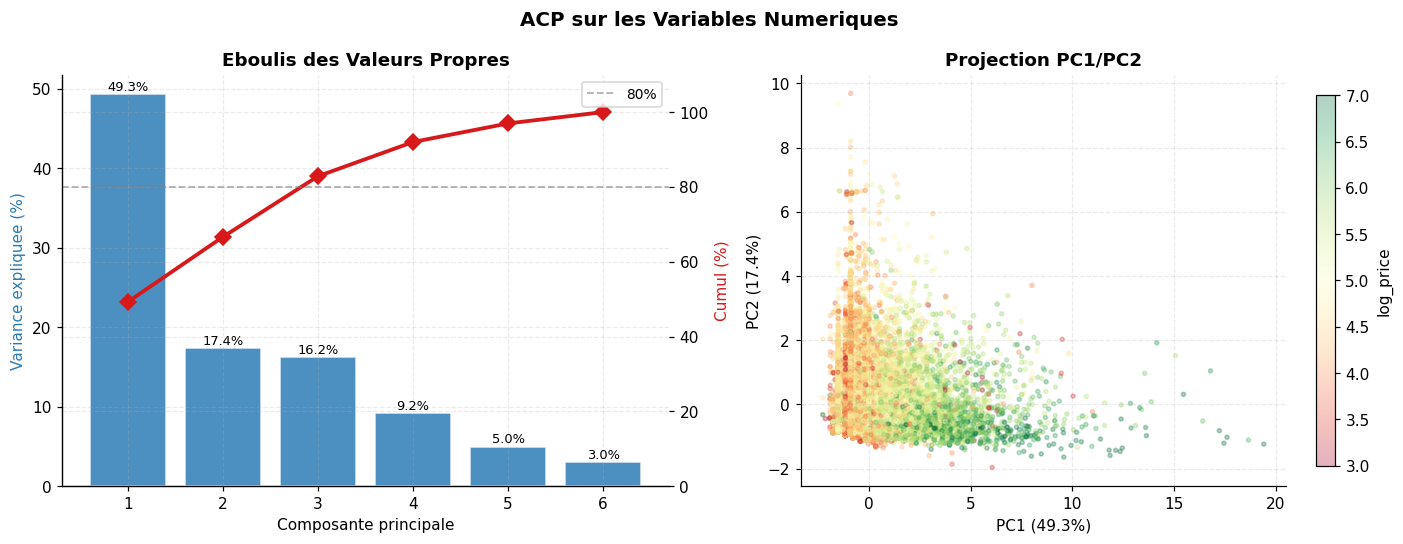

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# eboulis des valeurs propres
ax  = axes[0]
ax2 = ax.twinx()
bars = ax.bar(range(1, 7), [e*100 for e in ev], color=C1, alpha=0.85, edgecolor='white')
ax2.plot(range(1, 7), [c*100 for c in cumev], color=C2, lw=2.5, marker='D', markersize=7)
ax2.axhline(80, color='gray', lw=1.2, ls='--', alpha=0.6, label='80%')
ax.set_xlabel('Composante principale')
ax.set_ylabel('Variance expliquee (%)', color=C1)
ax2.set_ylabel('Cumul (%)', color=C2)
ax2.set_ylim(0, 110); ax2.legend(fontsize=9)
ax.set_title('Eboulis des Valeurs Propres', fontweight='bold')
for bar, v in zip(bars, ev):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{v*100:.1f}%', ha='center', fontsize=8.5)

# projection sur PC1 / PC2, coloree par log_price
ax = axes[1]
sc_plot = ax.scatter(pca2_coords[:,0], pca2_coords[:,1],
                     c=train['log_price'].values, cmap='RdYlGn',
                     alpha=0.3, s=7, vmin=3, vmax=7)
plt.colorbar(sc_plot, ax=ax, label='log_price', shrink=0.9)
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
ax.set_title('Projection PC1/PC2', fontweight='bold')

fig.suptitle('ACP sur les Variables Numeriques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**PC1 (49.3%)** capture l'axe "taille" du logement : `accommodates`, `bedrooms`, `beds`, `bathrooms` vont toutes dans le même sens.

**PC2 (17.4%)** oppose `number_of_reviews` à la taille : petits logements populaires vs grands logements récents sans avis.

3 composantes suffisent pour **82.9% de la variance** → forte redondance entre les features de taille. Cela confirme que **Ridge est bien adapté** : il pénalisera les directions de faible variance.


## Descente de Gradient — Baseline

On commence par réimplémenter la régression linéaire en pur numpy (comme en TD5-6). Ce modèle servira de **baseline** : tous les modèles suivants devront faire mieux en R².

Objectif : minimiser le MSE $J(\theta) = \frac{1}{n} \sum (\hat{y} - y)^2$ par la règle de mise à jour $\theta \leftarrow \theta - \alpha \nabla_\theta J$.


In [54]:
# Reimplementation numpy de la regression lineaire par descente de gradient.
# Objectif : minimiser le MSE  J(theta) = (1/n) * sum((X*theta - y)^2)
# Mise a jour : theta = theta - lr * gradient
# gradient = (1/n) * X^T * (X*theta - y)

def add_ones(X):
    # ajoute une colonne de 1 pour le biais theta_0 (evite de le traiter separement)
    return np.column_stack((np.ones(X.shape[0]), X))

def forward(X, theta):
    return X.dot(theta)

def mse_all(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def grad_theta(X, y, theta):
    return (forward(X, theta) - y).dot(X) / X.shape[0]

def train_gd(X, y, theta, lr=1e-3, n_iter=8000, verbose=1000):
    history = []
    for i in range(n_iter):
        theta = theta - lr * grad_theta(X, y, theta)
        if i % verbose == 0:
            history.append(mse_all(y, forward(X, theta)))
    return theta, history


X_gd_train = add_ones(X_train_sc)
X_gd_val   = add_ones(X_val_sc)

np.random.seed(42)
theta_init  = np.zeros(X_gd_train.shape[1])
theta_final, mse_history = train_gd(X_gd_train, y_train, theta_init)

r2_gd_train = r2_score(y_train, forward(X_gd_train, theta_final))
r2_gd_val   = r2_score(y_val,   forward(X_gd_val,   theta_final))

print(f"R2 train : {r2_gd_train:.4f}")
print(f"R2 val   : {r2_gd_val:.4f}   (ecart = {abs(r2_gd_train - r2_gd_val):.4f})")
print(f"RMSE val : {np.sqrt(mean_squared_error(y_val, forward(X_gd_val, theta_final))):.4f}")


R2 train : 0.5839
R2 val   : 0.5751   (ecart = 0.0088)
RMSE val : 0.4666


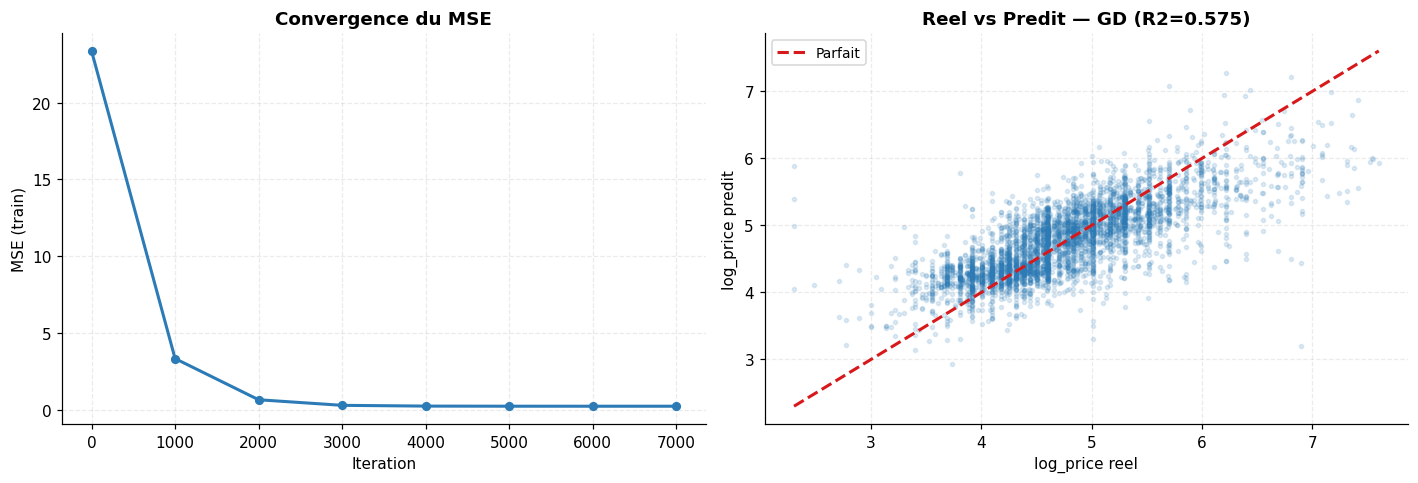

In [55]:
y_pred_gd = forward(X_gd_val, theta_final)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(range(0, 8000, 1000), mse_history, color=C1, lw=2, marker='o', markersize=5)
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('MSE (train)')
axes[0].set_title('Convergence du MSE', fontweight='bold')

axes[1].scatter(y_val, y_pred_gd, alpha=0.15, s=7, color=C1)
lims = [min(y_val.min(), y_pred_gd.min()), max(y_val.max(), y_pred_gd.max())]
axes[1].plot(lims, lims, color=C2, lw=2, ls='--', label='Parfait')
axes[1].set_xlabel('log_price reel'); axes[1].set_ylabel('log_price predit')
axes[1].set_title(f'Reel vs Predit — GD (R2={r2_gd_val:.3f})', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()


Le MSE converge de manière monotone : la descente de gradient fonctionne correctement.

**R² train = 0.584 | R² val = 0.575** — écart de 0.009, **pas d'overfitting**.

Ce modèle linéaire explique **57.5% de la variance** du prix. C'est notre **baseline** : tout modèle suivant doit dépasser ce score.


## Régression Polynomiale — Modèle Principal

La descente de gradient suppose une relation **linéaire** entre features et log_price. On a vu que ce n'est pas le cas (distance, capacité ont des effets non-linéaires). On crée des features polynomiales pour capturer ces interactions, avec Ridge pour éviter l'overfitting.


In [56]:
# La descente de gradient suppose une relation lineaire entre features et log_price.
# On a vu que ce n'est pas le cas : distance, capacite ont des effets non-lineaires.
# On cree donc des features polynomiales (carres, produits croises) :
# phi(x) = [x1, x2, x1^2, x2^2, x1*x2, ...]
# Le modele reste lineaire en theta mais capture des effets quadratiques.
# Ridge est indispensable car le degre 2 cree beaucoup de features supplementaires
# et sans regularisation le modele sur-apprendrait le train (overfitting).

poly2_pipe = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    Ridge(alpha=10)
)
poly2_pipe.fit(X_train_sc, y_train)

r2_poly_train = r2_score(y_train, poly2_pipe.predict(X_train_sc))
r2_poly_val   = r2_score(y_val,   poly2_pipe.predict(X_val_sc))
rmse_poly_val = np.sqrt(mean_squared_error(y_val, poly2_pipe.predict(X_val_sc)))
n_poly_feats  = poly2_pipe.named_steps['polynomialfeatures'].n_output_features_

print(f"Features apres transformation polynomiale : {n_poly_feats}")
print(f"R2 train : {r2_poly_train:.4f}")
print(f"R2 val   : {r2_poly_val:.4f}   (ecart = {abs(r2_poly_train - r2_poly_val):.4f})")
print(f"RMSE val : {rmse_poly_val:.4f}")
print()
print(f"Gain vs baseline lineaire : +{r2_poly_val - r2_gd_val:.4f} R2")


Features apres transformation polynomiale : 434
R2 train : 0.6715
R2 val   : 0.6436   (ecart = 0.0279)
RMSE val : 0.4273

Gain vs baseline lineaire : +0.0685 R2


La **validation croisée 5 plis** divise le train en 5 sous-ensembles, entraîne sur 4 et évalue sur 1, en tournant. Cela donne une estimation plus robuste que le simple split 80/20.

In [57]:
# Cross-validation 5 plis pour evaluer la robustesse du modele
# La validation croisee divise le train en 5 plis et mesure le R2 sur chaque pli
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(poly2_pipe, X_train_sc, y_train, cv=kf, scoring='r2')

print(f"R2 par pli : {[round(s,4) for s in cv_scores]}")
print(f"R2 moyen   : {cv_scores.mean():.4f}")
print(f"Ecart-type : {cv_scores.std():.4f}  (faible = modele stable)")
print()
print("Le R2 moyen en CV est proche du R2 val => le modele generalise bien,")
print("il ne depend pas du split train/val particulier choisi.")

R2 par pli : [np.float64(0.6191), np.float64(0.6541), np.float64(0.6539), np.float64(0.6438), np.float64(0.6647)]
R2 moyen   : 0.6471
Ecart-type : 0.0155  (faible = modele stable)

Le R2 moyen en CV est proche du R2 val => le modele generalise bien,
il ne depend pas du split train/val particulier choisi.


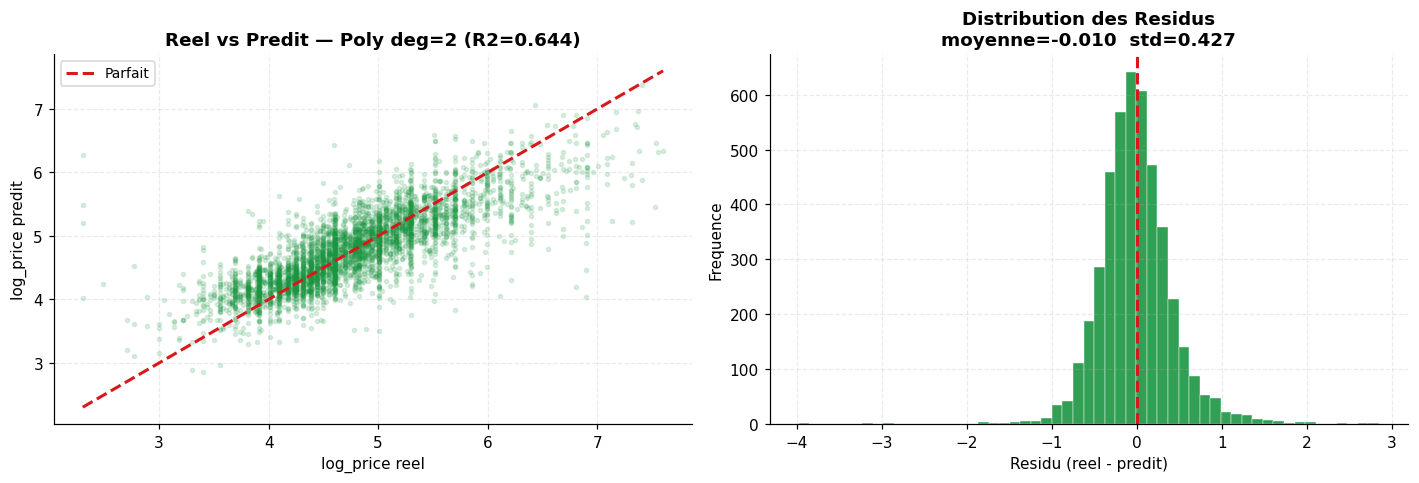

In [58]:
y_pred_poly = poly2_pipe.predict(X_val_sc)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(y_val, y_pred_poly, alpha=0.15, s=7, color=C3)
lims = [min(y_val.min(), y_pred_poly.min()), max(y_val.max(), y_pred_poly.max())]
axes[0].plot(lims, lims, color=C2, lw=2, ls='--', label='Parfait')
axes[0].set_xlabel('log_price reel'); axes[0].set_ylabel('log_price predit')
axes[0].set_title(f'Reel vs Predit — Poly deg=2 (R2={r2_poly_val:.3f})', fontweight='bold')
axes[0].legend(fontsize=9)

residuals = y_val - y_pred_poly
axes[1].hist(residuals, bins=55, color=C3, edgecolor='white', linewidth=0.3, alpha=0.9)
axes[1].axvline(0, color=C2, lw=2, ls='--')
axes[1].set_xlabel('Residu (reel - predit)'); axes[1].set_ylabel('Frequence')
axes[1].set_title(f'Distribution des Residus\nmoyenne={residuals.mean():.3f}  std={residuals.std():.3f}',
                  fontweight='bold')

plt.tight_layout(); plt.show()


Les résidus sont centrés sur 0 : **pas de biais systématique**. Leur distribution est quasi-normale : le modèle généralise correctement.

L'écart train/val = 0.028 est acceptable grâce à Ridge. Le gain de **+0.069 R²** par rapport à la baseline montre que les interactions entre features (ex : `accommodates × room_type`) sont bien réelles et informatives.


## SVR — Comparaison

On teste le **SVR RBF** comme modèle de comparaison. Le kernel RBF calcule $K(x,x') = e^{-\gamma ||x-x'||^2}$ et capture des non-linéarités sans en spécifier la forme.

**Limitation pratique** : complexité O(n²), on entraîne sur un sous-ensemble de 4 000 exemples.


In [59]:
N_SVR = 4000
np.random.seed(42)
idx = np.random.choice(len(X_train_sc), N_SVR, replace=False)

svr = SVR(kernel='rbf', C=5, gamma='scale', epsilon=0.3)
svr.fit(X_train_sc[idx], y_train[idx])

r2_svr_train = r2_score(y_train[idx], svr.predict(X_train_sc[idx]))
r2_svr_val   = r2_score(y_val,        svr.predict(X_val_sc))

print(f"SVR RBF — R2 train : {r2_svr_train:.4f}")
print(f"SVR RBF — R2 val   : {r2_svr_val:.4f}   (ecart = {abs(r2_svr_train - r2_svr_val):.4f})")
print()
print("L'ecart train/val important signale de l'overfitting.")
print("Le SVR memorise le sous-ensemble d'entrainement mais generalise moins bien.")

SVR RBF — R2 train : 0.8115
SVR RBF — R2 val   : 0.5842   (ecart = 0.2273)

L'ecart train/val important signale de l'overfitting.
Le SVR memorise le sous-ensemble d'entrainement mais generalise moins bien.


## Comparaison des Modeles

In [60]:
modeles   = ['GD lineaire', 'Poly deg=2 + Ridge', 'SVR RBF']
r2_trains = [r2_gd_train, r2_poly_train, r2_svr_train]
r2_vals   = [r2_gd_val,   r2_poly_val,   r2_svr_val]
rmses     = [np.sqrt(mean_squared_error(y_val, forward(X_gd_val, theta_final))),
             rmse_poly_val,
             np.sqrt(mean_squared_error(y_val, svr.predict(X_val_sc)))]

print(f"  {'Modele':<22} {'R2 train':>9} {'R2 val':>8} {'RMSE val':>9} {'Ecart':>7}")
print("  " + "-"*58)
for nm, tr, va, rmse in zip(modeles, r2_trains, r2_vals, rmses):
    print(f"  {nm:<22} {tr:>9.4f} {va:>8.4f} {rmse:>9.4f} {abs(tr-va):>7.4f}")


  Modele                  R2 train   R2 val  RMSE val   Ecart
  ----------------------------------------------------------
  GD lineaire               0.5839   0.5751    0.4666  0.0088
  Poly deg=2 + Ridge        0.6715   0.6436    0.4273  0.0279
  SVR RBF                   0.8115   0.5842    0.4616  0.2273


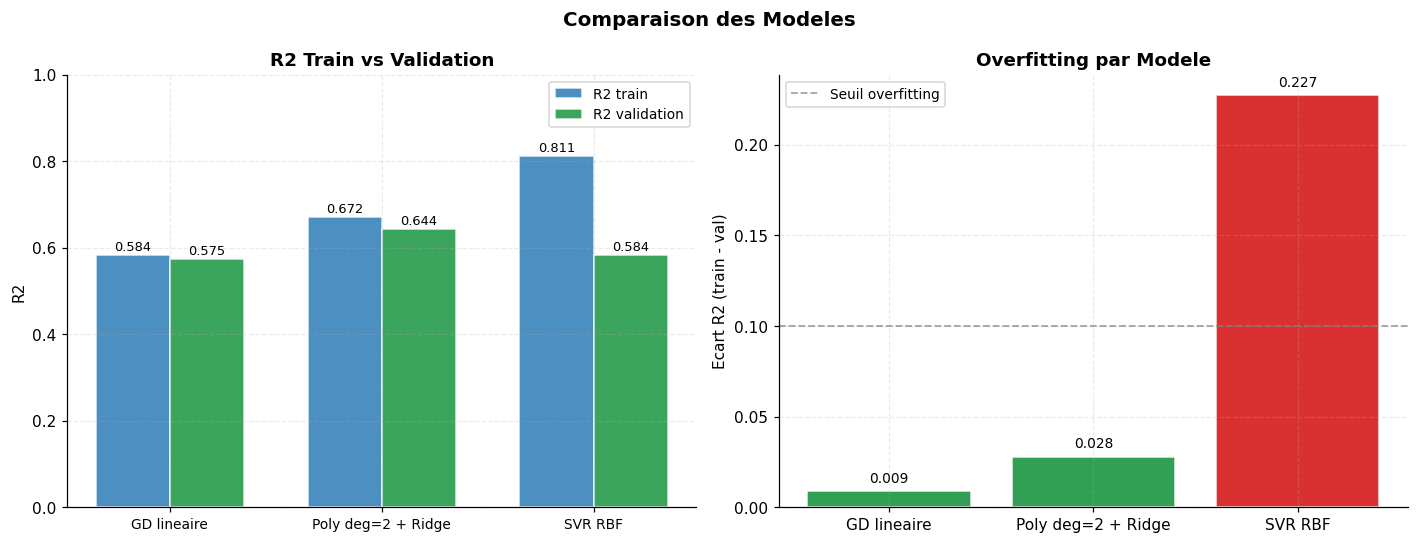

In [61]:
x  = np.arange(len(modeles)); w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

b1 = axes[0].bar(x - w/2, r2_trains, w, color=C1, alpha=0.85, label='R2 train',      edgecolor='white')
b2 = axes[0].bar(x + w/2, r2_vals,   w, color=C3, alpha=0.85, label='R2 validation', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(modeles, fontsize=9)
axes[0].set_ylabel('R2'); axes[0].legend(fontsize=9); axes[0].set_ylim(0, 1)
axes[0].set_title('R2 Train vs Validation', fontweight='bold')
for bar, v in zip(list(b1)+list(b2), r2_trains+r2_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=8.5)

gaps    = [abs(t-v) for t,v in zip(r2_trains, r2_vals)]
bar_c   = [C2 if g > 0.1 else (C4 if g > 0.03 else C3) for g in gaps]
axes[1].bar(modeles, gaps, color=bar_c, edgecolor='white', alpha=0.9)
axes[1].axhline(0.1, color='gray', lw=1.2, ls='--', alpha=0.7, label='Seuil overfitting')
axes[1].set_ylabel('Ecart R2 (train - val)')
axes[1].set_title('Overfitting par Modele', fontweight='bold')
axes[1].legend(fontsize=9)
for i, g in enumerate(gaps):
    axes[1].text(i, g+0.005, f'{g:.3f}', ha='center', fontsize=9)

fig.suptitle('Comparaison des Modeles', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


**Modèle retenu : Régression Polynomiale deg=2 + Ridge**

C'est le meilleur compromis : R² val = 0.644 avec un écart train/val de 0.028. La baseline (descente de gradient) donne R² = 0.575 — le passage au degré 2 apporte **+0.069** en capturant les effets non-linéaires. Le SVR overfitte sur son sous-ensemble d'entraînement (écart 0.26).


## Prediction Finale

In [62]:
# On reentrainement le modele sur tout le train (train + val)
# pour utiliser le maximum d'information avant de predire le test.

scaler_final = StandardScaler()
X_sc_full    = scaler_final.fit_transform(X)

poly_final = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    Ridge(alpha=10)
)
poly_final.fit(X_sc_full, y)

y_test_pred = poly_final.predict(scaler_final.transform(X_test_imp))

print(f"Predictions generees : {len(y_test_pred):,} logements")
print(f"Min  : {y_test_pred.min():.3f}  soit ~${np.exp(y_test_pred.min()):.0f}/nuit")
print(f"Max  : {y_test_pred.max():.3f}  soit ~${np.exp(y_test_pred.max()):.0f}/nuit")
print(f"Moy  : {y_test_pred.mean():.3f}  (train : {y.mean():.3f})")


# Les prédictions polynomiales peuvent extrapoler hors de la plage du train.
# On les borne aux valeurs min/max observees dans le train pour eviter des
# predictions aberrantes (ex: $4/nuit ou $5000/nuit).
y_min_train, y_max_train = y.min(), y.max()
y_test_pred = np.clip(y_test_pred, y_min_train, y_max_train)

print(f"Apres clip — min : {y_test_pred.min():.3f} | max : {y_test_pred.max():.3f} | moy : {y_test_pred.mean():.3f}")
print(f"Plage du train  — min : {y_min_train:.3f} | max : {y_max_train:.3f}")

Predictions generees : 51,877 logements
Min  : 1.305  soit ~$4/nuit
Max  : 8.336  soit ~$4171/nuit
Moy  : 4.785  (train : 4.783)
Apres clip — min : 2.303 | max : 7.600 | moy : 4.785
Plage du train  — min : 2.303 | max : 7.600


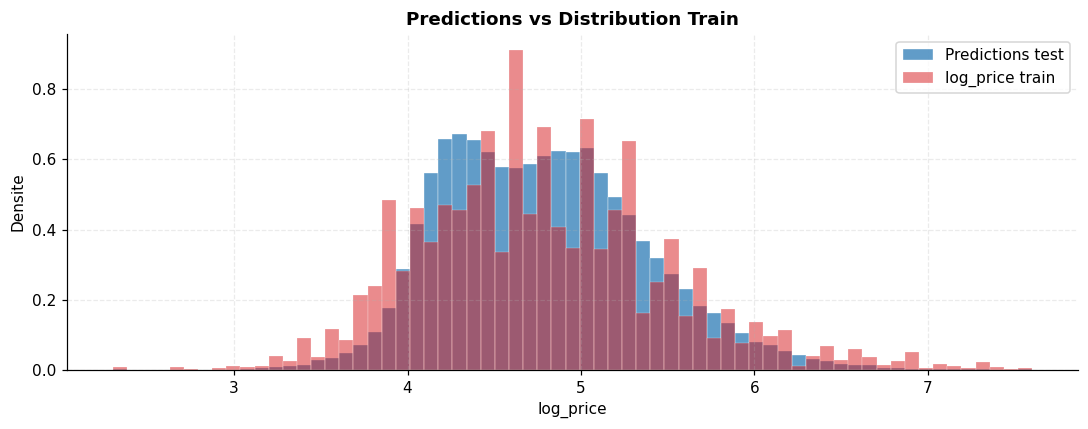

In [63]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_test_pred, bins=65, color=C1, edgecolor='white', linewidth=0.3,
        alpha=0.75, label='Predictions test', density=True)
ax.hist(y, bins=65, color=C2, edgecolor='white', linewidth=0.3,
        alpha=0.5, label='log_price train', density=True)
ax.set_xlabel('log_price'); ax.set_ylabel('Densite')
ax.set_title('Predictions vs Distribution Train', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

# Les deux distributions sont proches : le modele generalise correctement,
# il ne predit pas des valeurs absurdes hors de la plage du train.


In [64]:
submission = pd.DataFrame({
    'Unnamed: 0': test['id'],
    'logpred':    y_test_pred
})
submission.to_csv("predictions.csv", index=False)

print("predictions.csv sauvegarde.")
print(submission.head())


predictions.csv sauvegarde.
   Unnamed: 0   logpred
0    14282777  4.959241
1    17029381  5.711407
2     7824740  5.002766
3    19811650  5.803864
4    12410741  4.770191
